In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna
os.chdir('C:\\Users\\ferna\\OneDrive\\Downloads\\Code\\Python\\ML_Factor')

In [61]:
from data.data_load import *

In [62]:
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings(
    "ignore",
    message="Some inputs do not have OOB scores.*"
)

# Your code here

## 6.1) Regression Tree

In [31]:
from sklearn import tree

### `DecisionTreeRegressor` Parameters

```python
DecisionTreeRegressor(
    *,
    criterion="squared_error", # “absolute_error”, “poisson”
    splitter="best",           # random
    max_depth=None,
    min_samples_split=2,       
    min_samples_leaf=1,        # if int (minimum number), if float (ceil(min_samples_leaf * n_samples))
    min_weight_fraction_leaf=0.0,
    max_features=None,         # number of features to consider when looking for the best split. As in RF.
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    monotonic_cst=None, #Indicates the monotonicity constraint to enforce on each feature. 1: monotonic increase, 0: no constraint -1: monotonic    decrease. With monotonic constraints, some splits are rejected because they would violate the required ordering of the leaf predictions.
)

### hyperparameter tuning

There are too many options of hyperparameters to optimize in regression trees: (1) max_depth, (2) min_samples_split, (3) min_samples_leaf, (4) max_leaf_nodes, (5) min_impurity_decrease and (6) ccp_alpha. Optimizing for all hyperparameters may lead to a model that fits the data very specifically, which may lead to overfitting.

We propose a simple heuristic to solve this issue and find an 'optimized' model:

1. Set max_depth and min_samples_leaf using a priori reasoning. Avoid overly restrictive values; choose the minimum acceptable constraints.
2. Choosing overly permissive values increases training time.
3. Then compute the cost_complexity_pruning_path.
4. Find the best ccp_alpha by cross-validation.

### alpha eff

The cost-complexity criterion is

$$
R_\alpha(T)=R(T)+\alpha|T|,
$$

where $R(T)$ is the total tree impurity for $\alpha = 0$ and $|T|$ is the number of leaves. For a subtree $T_t$, pruning replaces it by the single leaf $t$. The critical value of $\alpha$ satisfies

$$
R(T_t)+\alpha|T_t|
=
R(t)+\alpha,
$$

yielding

$$
\boxed{
\alpha_{\mathrm{eff}}(t)
=
\frac{R(t)-R(T_t)}
{|T_t|-1}.
}
$$

The cost_complexity_pruning_path is computed as follows:

1. Grow the full tree.
2. Compute $\alpha_{\mathrm{eff}}(t)$ for every internal node.
3. Prune the subtree with the smallest  $\alpha_{\mathrm{eff}}(t)$ (the weakest link).
4. Recompute  $\alpha_{\mathrm{eff}}(t)$ and repeat until only the root remains.

The resulting sequence of pruning parameters is returned in `path.ccp_alphas`.

### Exercise

In [51]:
X_train = data_ml.loc[idx_train,features]
X_test  = data_ml.loc[idx_test,features]
y_train = data_ml.loc[idx_train,'R1M_Usd']
y_test  = data_ml.loc[idx_test,'R1M_Usd']

In [52]:
# Include max_depth when optimizing for ccp_alpha to avoid super deep trees
m_tree = tree.DecisionTreeRegressor(
    criterion="squared_error",
    max_depth = 6,
    min_samples_leaf=0.01,
    ccp_alpha=0.0)

In [54]:
path = m_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.00000000e+00, 4.70021113e-07, 4.87740054e-07, 1.02196063e-06,
       1.12202772e-06, 1.75731811e-06, 2.39256070e-06, 2.76869309e-06,
       2.92540963e-06, 3.67763418e-06, 5.12160293e-06, 6.14884013e-06,
       9.37412998e-06, 1.09551259e-05, 1.10367472e-05, 3.79087891e-05,
       5.25934171e-05])

In [57]:
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = []

for alpha in ccp_alphas:
    model = tree.DecisionTreeRegressor(
        criterion="squared_error",
        max_depth=6,
        min_samples_leaf=0.01,
        ccp_alpha=alpha,
        random_state=711
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    ).mean()

    cv_scores.append(score)

cv_scores = np.array(cv_scores)

best_alpha = ccp_alphas[np.argmax(cv_scores)]

print(f"Best alpha: {best_alpha:.6f}")
print(f"Best CV MSE: {-cv_scores.max():.4f}")

Best alpha: 0.000001
Best CV MSE: 0.0289


In [60]:
# Optimal tree
mopt_tree = tree.DecisionTreeRegressor(
        criterion="squared_error",
        max_depth = 6,
        min_samples_leaf=0.01,
        ccp_alpha=best_alpha)
mopt_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=np.float64(1.0219606318395127e-06), max_depth=6,
                      min_samples_leaf=0.01)

In [65]:
mopt_tree.predict(X_train.iloc[0:6])

array([0.01706478, 0.01706478, 0.01706478, 0.11579263, 0.11579263,
       0.11579263])

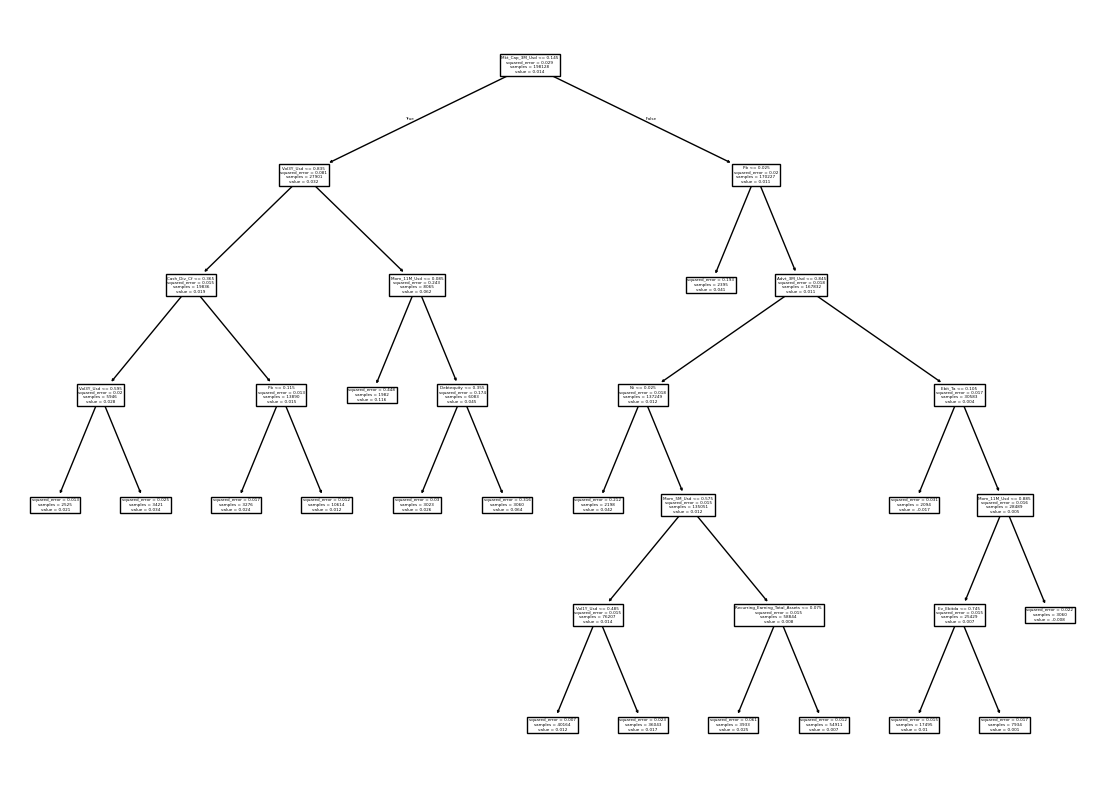

In [67]:
fig, ax = plt.subplots(figsize=(14, 10)) # resizing
tree.plot_tree(mopt_tree,feature_names=features, ax=ax) # Plot the tree
plt.show()

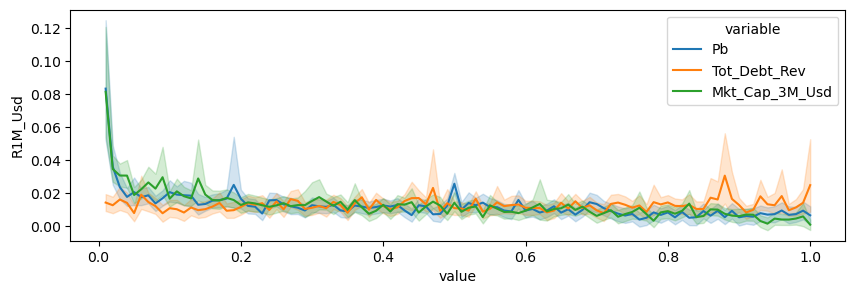

In [73]:
# See impact of some variables on returns
import seaborn as sns
unpivoted_data_ml = pd.melt(data_ml[['R1M_Usd','Pb','Tot_Debt_Rev','Mkt_Cap_3M_Usd']], id_vars='R1M_Usd') # selecting and putting in vector
plt.figure(figsize=(10, 3))
sns.lineplot(data = unpivoted_data_ml, y='R1M_Usd', x='value', hue='variable'); # Plot from seaborn

In [74]:
unpivoted_data_ml.head(2)

,R1M_Usd,variable,value
0,0.089,Pb,0.5
1,0.039,Pb,0.5


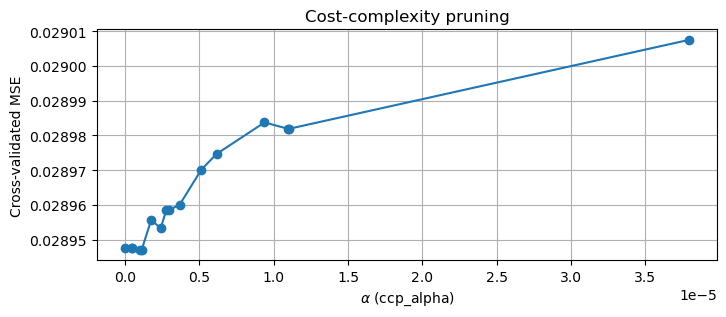

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(ccp_alphas[:-1], -cv_scores[:-1], marker="o")
plt.xlabel(r"$\alpha$ (ccp_alpha)")
plt.ylabel("Cross-validated MSE")
plt.title("Cost-complexity pruning")
plt.grid(True)
plt.show()

In [72]:
# MSE and hit ratio
print(f'MSE: {np.mean((mopt_tree.predict(X_test) - y_test)**2)}')
print(f'Hit Ratio: {np.mean(mopt_tree.predict(X_test) * y_test > 0)}')

MSE: 0.037026760793475104
Hit Ratio: 0.5447669781221514


## 6.2) Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor
import optuna
from sklearn.model_selection import cross_val_score

In [28]:
help(RandomForestRegressor)

Help on class RandomForestRegressor in module sklearn.ensemble._forest:

class RandomForestRegressor(ForestRegressor)
 |  RandomForestRegressor(
 |      n_estimators=100,
 |      *,
 |      criterion='squared_error',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features=1.0,
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest regressor.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  regressors on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"

```python
RandomForestRegressor(
    n_estimators=100,              # Number of trees - M
    criterion='squared_error',     # {"squared_error", "absolute_error", "friedman_mse", "poisson"}
    max_depth=None,                # int
    min_samples_split=2,           # int or float
    min_samples_leaf=1,            # int or float
    min_weight_fraction_leaf=0.0,  # Minimum weighted fraction of samples in a leaf. Used with rf.fit(X, y, sample_weight=weights).
    max_features=1.0,              # {"sqrt", "log2", None}, int or float, 1.0 uses all features
    max_leaf_nodes=None,           # Maximum number of leaf nodes
    min_impurity_decrease=0.0,     # Minimum impurity decrease required for a split
    bootstrap=True,                # True: use bootstrap sampling; False: use whole dataset.
    oob_score=False,               # Compute out-of-bag score. Only available if `bootstrap=True`.
    n_jobs=None,                   # Number of parallel jobs. k jobs, -1 to use all available.
    random_state=None,             # Used in bootstrapping and sampling of the features.
    verbose=0,                     
    warm_start=False,              # True: Reuse previous solution and add more trees, False: fit again.
    ccp_alpha=0.0,                 # Cost-complexity pruning parameter. Tuning often uses other hyperparameters.
    max_samples=None,              # None (draw N), int, float.
    monotonic_cst=None             # Monotonicity constraints
)
```

### Methods

* estimators_ : list of DecisionTreeRegressor
* feature_importances_ + feature_names_in_
* oob_score_
* oob_prediction_
* fit(X, y, sample_weight=None)
* predict(X)
### Hyperparameter tuning
1. RFs do not use ccp_alpha for tuning, because individual trees in a Random Forest are intentionally grown deep, and averaging many such trees reduces variance. Moreover it is not sensible for trees with different splitting features to have the same ccp_alpha.
2. min_samples_leaf and/or max_depth generalize better to many trees.
3. n_estimators: the bigger the better (more reduction in variance). However, training becomes slow.
4. max_features: heuristic is 0.3, but you can tune it to find optimal trade-off between decorrelation of trees and increase of variance in individual trees
5. My recomendation.
   * Start with the heuristic values `min_samples_leaf = 0.001`, `max_depth = 10` (deep trees), and `max_features = 0.3`. Monitor the OOB score as `n_estimators` increases.
    * The OOB score is given by the R^2 of the tree. So it increases with n_estimators. If you compute a loss measure than it should decrease.
    * obs: since there is randomness in feature selection and bootstrapping, the oob_score may not increase in some iterations.
    * Choose a conservative value for `n_estimators`, then optimize `min_samples_leaf`, `max_depth`, and `max_features` using oob_score within a Bayesian Optimization framework.
    * Tip: avoid CV, since it requires more time. oob_score already provides measure for generalization error.
    * Verify if the OOB score has more to decrease after tuning. If necessary adjust `n_estimators` and reoptimize the hyperparameters.
    * Perform comparisions to heuristics, such as `min_samples_leaf = 0.01` and/or `max_depth = 10` and/or `max_features = 0.3`.


In [29]:
X_train = data_ml.loc[idx_train,features]
X_test  = data_ml.loc[idx_test,features]
y_train = data_ml.loc[idx_train,'R1M_Usd']
y_test  = data_ml.loc[idx_test,'R1M_Usd']

In [30]:
# Train the Random Forest incrementally by adding 5 trees at a time (warm_start=True) and monitor the OOB score until it stabilizes.

m1_rf = RandomForestRegressor(
    n_estimators=5,
    max_depth=10,
    max_features=0.3,
    min_samples_leaf=0.001,
    bootstrap=True,
    oob_score=True,
    warm_start=True,
    n_jobs=4,
    random_state=42,
)

oob_scores = []

while True:

    m1_rf.fit(X_train, y_train)
    oob_scores.append(m1_rf.oob_score_)
    print(f"Trees: {m1_rf.n_estimators}, "
        f"OOB: {m1_rf.oob_score_:}")
    if len(oob_scores) > 1:
        thresh = oob_scores[-1] - oob_scores[-2]
        if thresh < 1e-5:
            break

    m1_rf.n_estimators += 5

Trees: 5, OOB: -0.0002376925834610688
Trees: 10, OOB: 0.003920265751117147
Trees: 15, OOB: 0.00564243791638086
Trees: 20, OOB: 0.006832448768879118
Trees: 25, OOB: 0.007214503154864271
Trees: 30, OOB: 0.007564606487200254
Trees: 35, OOB: 0.007704070408323216
Trees: 40, OOB: 0.0077142920294825945
Trees: 45, OOB: 0.00783388239813787
Trees: 50, OOB: 0.007884773253495125
Trees: 55, OOB: 0.007947917250743397
Trees: 60, OOB: 0.008016150327677107
Trees: 65, OOB: 0.007928629339537085


In [31]:
# Let's set n_estimators = 100
# I should be more conservative, but Bayesian optimization demans a lot

### Bayesian Optimization

In [41]:
def objective(trial):

    model = RandomForestRegressor(
        n_estimators=90,
        max_depth=trial.suggest_int("max_depth", 5, 20),
        max_features=trial.suggest_float("max_features", 0.1, 0.9),
        min_samples_leaf=trial.suggest_float("min_samples_leaf", 1e-4, 0.05, log=True), # sample on log scale
        bootstrap=True,
        random_state=42,
        oob_score=True,
        n_jobs=-1,
    )

    score = model.fit(X_train, y_train).oob_score_ # CV takes longer to train, can be avoided here

    return score

In [42]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20) # Run more if yu want better results.

[I 2026-07-02 01:03:54,379] A new study created in memory with name: no-name-5fc5a6c0-5cea-4e57-ac43-24f30118ce34
[I 2026-07-02 01:04:19,014] Trial 0 finished with value: 0.005758706550839654 and parameters: {'max_depth': 11, 'max_features': 0.8598664249103262, 'min_samples_leaf': 0.015536137996634117}. Best is trial 0 with value: 0.005758706550839654.
[I 2026-07-02 01:04:54,588] Trial 1 finished with value: 0.007805135308971534 and parameters: {'max_depth': 18, 'max_features': 0.5569382109663905, 'min_samples_leaf': 0.0003756813254587718}. Best is trial 1 with value: 0.007805135308971534.
[I 2026-07-02 01:05:03,657] Trial 2 finished with value: 0.003826176207048948 and parameters: {'max_depth': 19, 'max_features': 0.38172758276643914, 'min_samples_leaf': 0.04677857631542673}. Best is trial 1 with value: 0.007805135308971534.
[I 2026-07-02 01:05:15,341] Trial 3 finished with value: 0.007813810480613914 and parameters: {'max_depth': 8, 'max_features': 0.2956232119452705, 'min_samples_le

In [43]:
study.best_value

0.008467520911757287

In [44]:
study.best_params

{'max_depth': 20,
 'max_features': 0.4660003088815027,
 'min_samples_leaf': 0.000926488698443308}

In [45]:
best_model = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, max_features=0.4660003088815027,
                      min_samples_leaf=0.000926488698443308, n_jobs=-1,
                      random_state=42)

In [46]:
best_model.predict(X_test)

array([0.08990249, 0.10601319, 0.11125227, ..., 0.01112648, 0.00749468,
       0.00912386])

In [47]:
# MSE and hit ratio
print(f'MSE: {np.mean((best_model.predict(X_test) - y_test)**2)}')
print(f'Hit Ratio: {np.mean(best_model.predict(X_test) * y_test > 0)}')

MSE: 0.03684825298489862
Hit Ratio: 0.5414767547857794


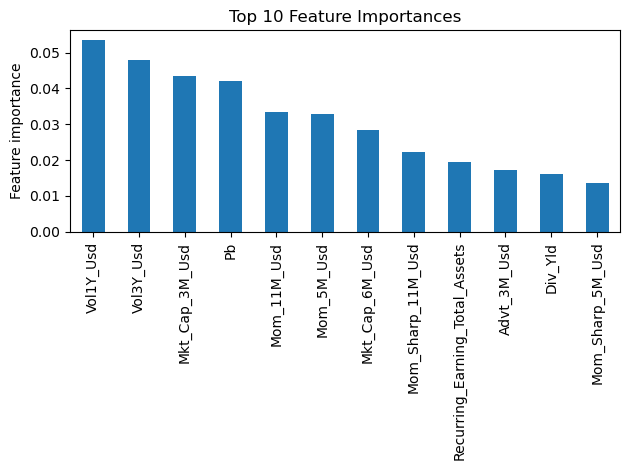

In [54]:
# Feature importances - gini
# Can also use permutation choice
importance = pd.Series(best_model.feature_importances_,index=X_train.columns).sort_values(ascending=False)

importance.head(12).plot(kind="bar")
plt.ylabel("Feature importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

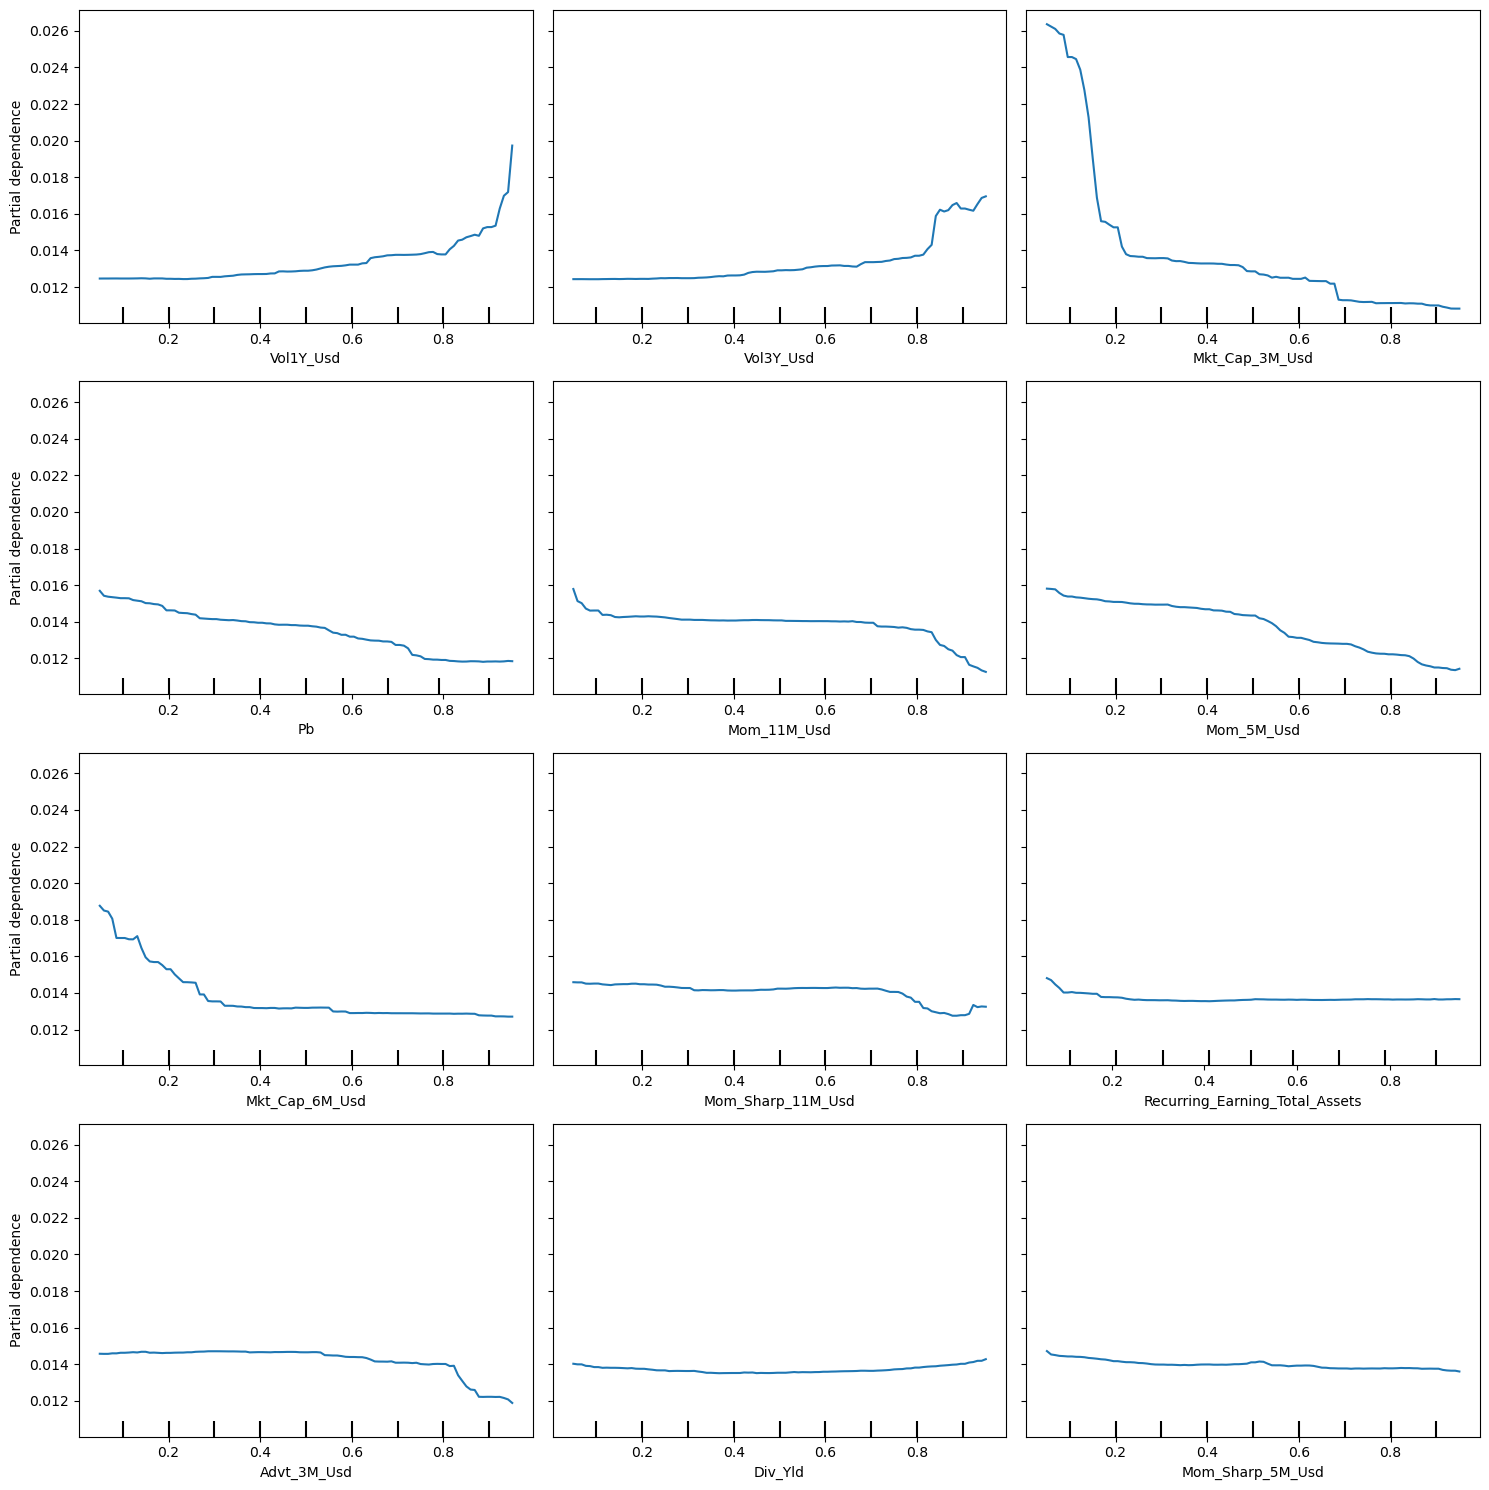

In [58]:
# Partial dependency plots

from sklearn.inspection import PartialDependenceDisplay
# Top 12 most important features
top12_features = importance.head(12).index.tolist()

# 3x3 grid of Partial Dependence Plots
fig, ax = plt.subplots(4, 3, figsize=(15, 15))

PartialDependenceDisplay.from_estimator(
    best_model,
    X_train,
    features=top12_features,
    ax=ax,
    kind="average",   # Partial Dependence Plot
    grid_resolution=100,
)

plt.tight_layout()
plt.show()

In [59]:
from sklearn.ensemble import RandomForestClassifier
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(
 |      n_estimators=100,
 |      *,
 |      criterion='gini',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features='sqrt',
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to p